Verwendetes Parameter-Dict: default_params_2


/var/folders/3q/_wl3lf3179gcd3z2kdgr6g940000gn/T/ipykernel_31746/2050488453.py:299: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


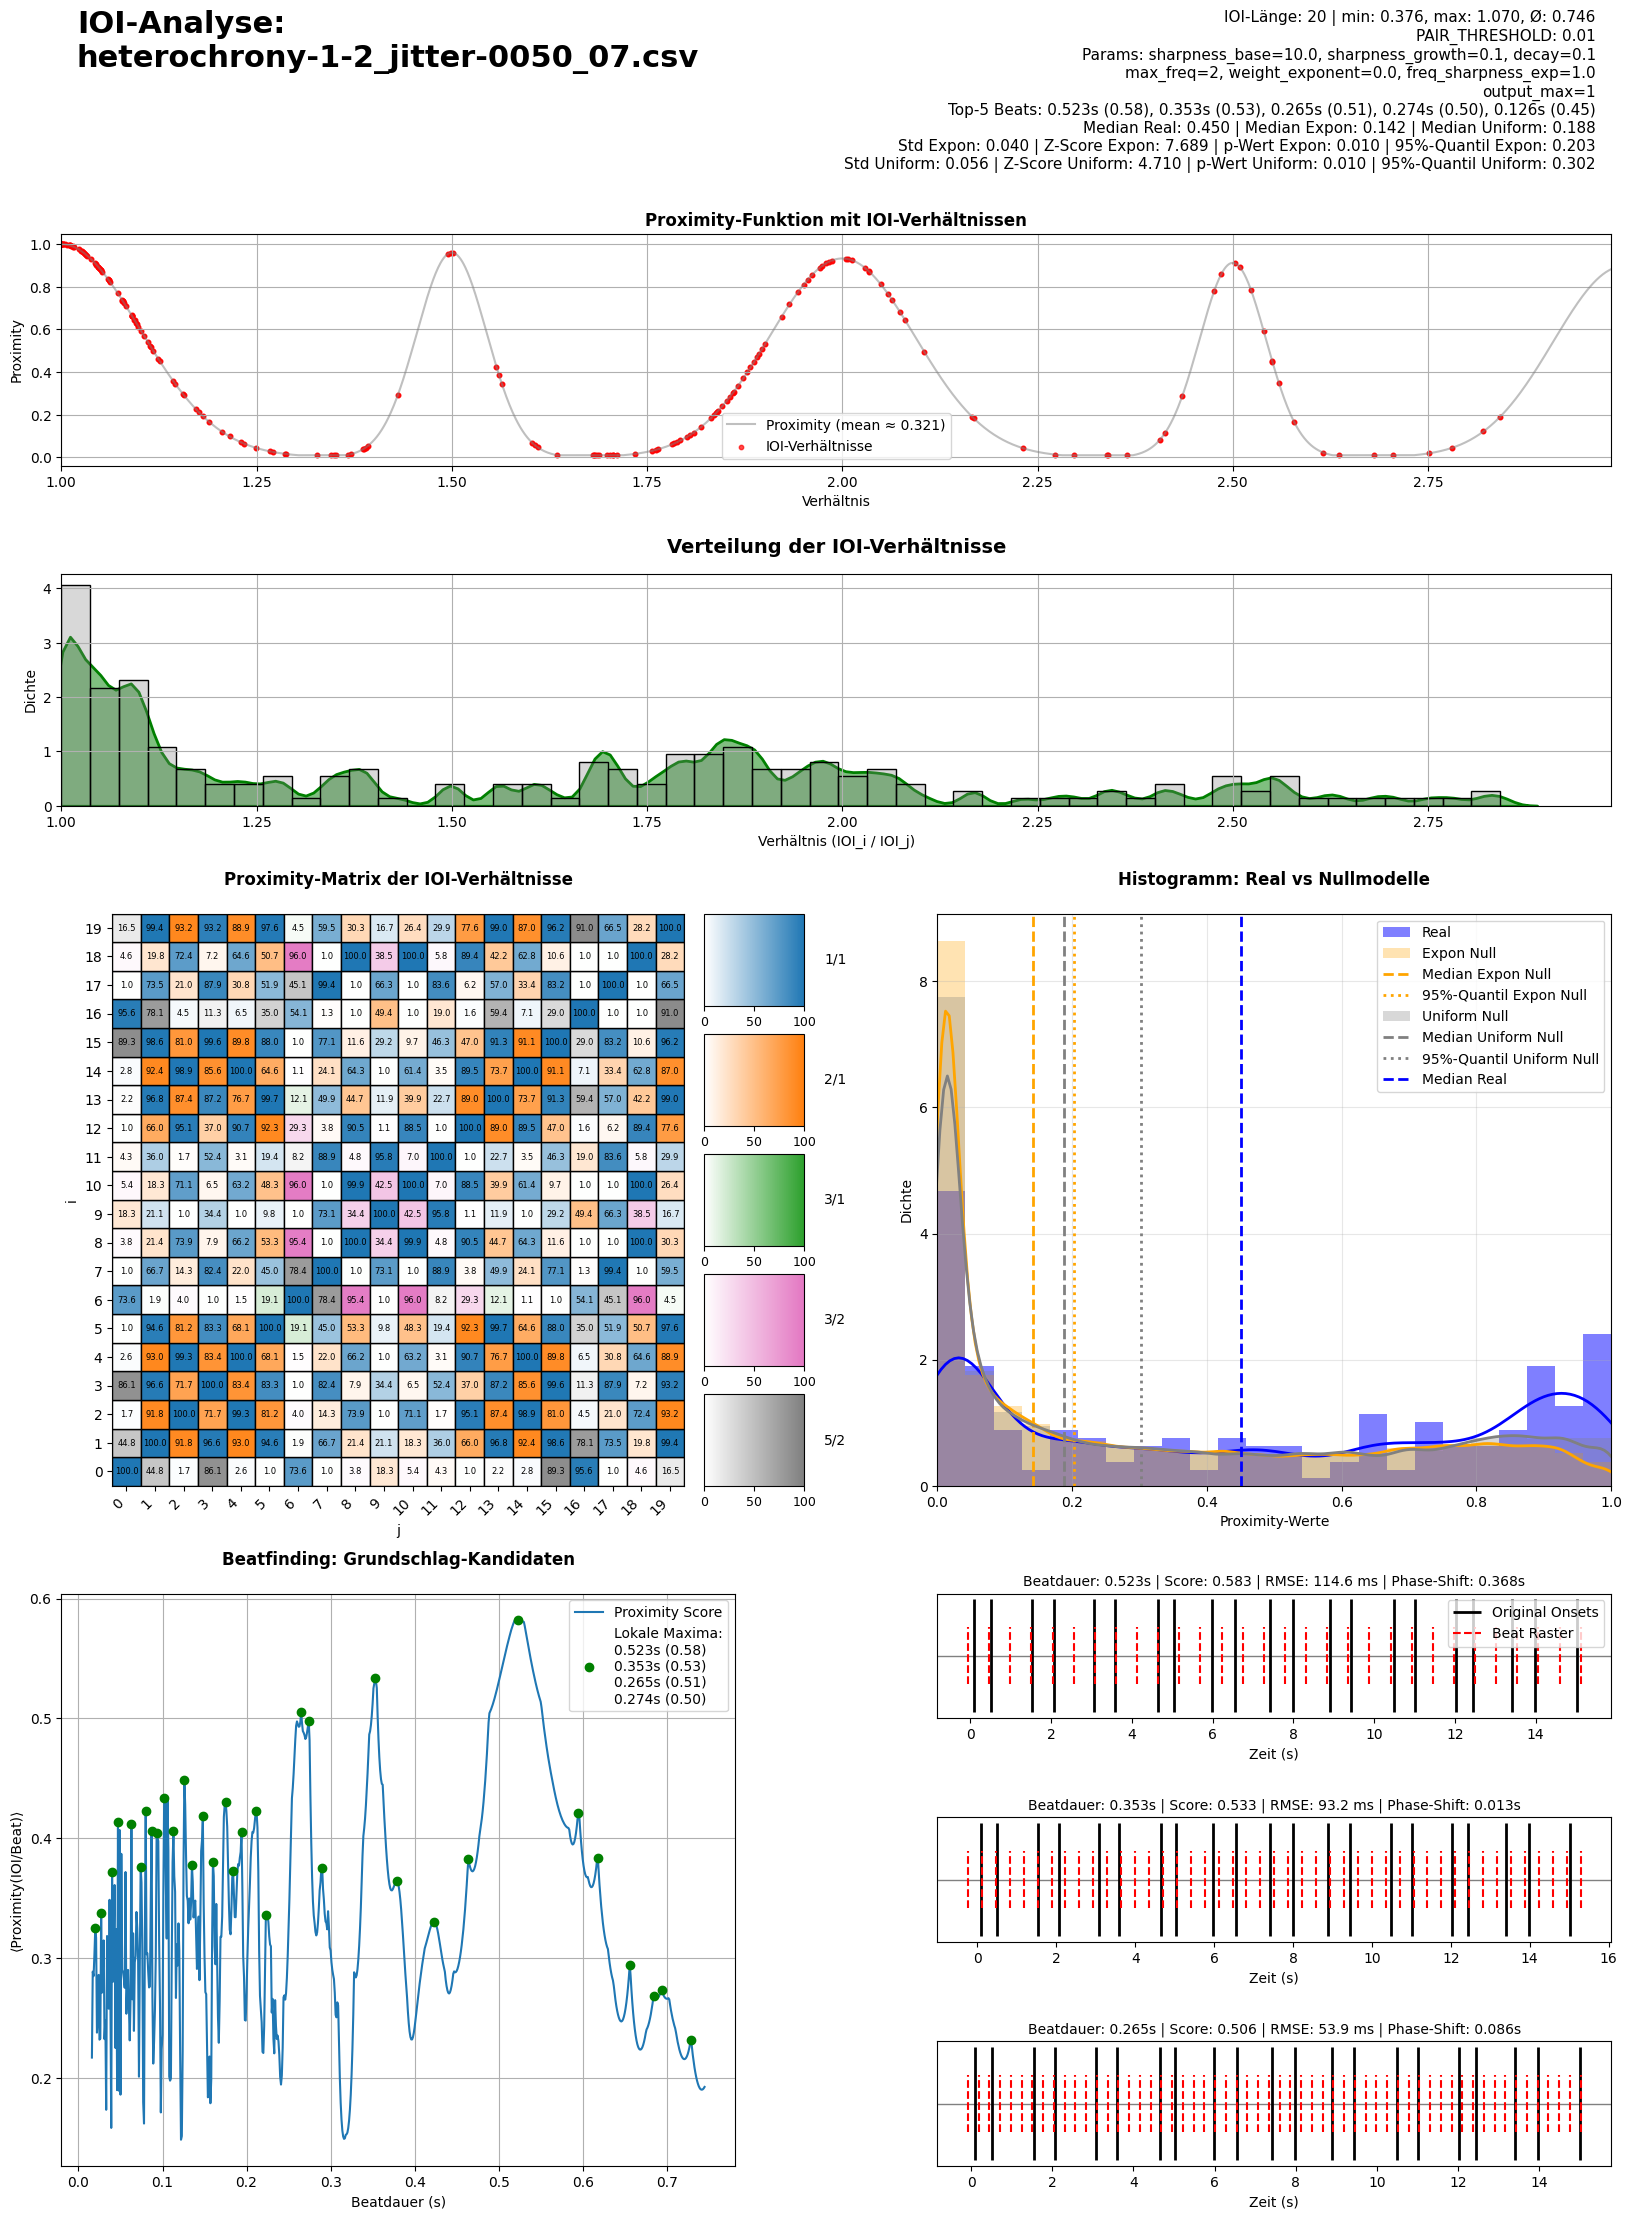

In [ ]:
# ===============================================
# IOI-Analyse & Beat-Detektion
# ===============================================

# =============================
# 0) Imports
# =============================
import sys
from pathlib import Path
import importlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.integrate import simpson
from scipy.signal import argrelextrema
from fractions import Fraction
from collections import Counter
from functools import reduce
from math import gcd
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpecFromSubplotSpec
from tabulate import tabulate

# übergeordneten Ordner hinzufügen
sys.path.append(str(Path("..").resolve()))

# Proximity-Library laden
import proximitylib.proximity as prox
importlib.reload(prox)

# =============================
# 1) Parameter, Daten laden & Pairs bauen
# =============================
# =============================
# 0) Datei + Parameter Auswahl
# =============================
from pathlib import Path
import proximitylib.proximity as prox

# === Datei auswählen ===
filename = "heterochrony-1-2_jitter-0050_07.csv"
base_dir = Path("/Users/emilschmiedl/Desktop/Proximity-Funktion/data/theoretical_sequences/baseIOI-0.50/20beats/")
seq_path = base_dir / filename

# === Parameter-Set auswählen ===
param_choice = 2         # choose "iso", 1, 2, 3, or 4
params = prox.param_sets[param_choice]
print(f"Verwendetes Parameter-Dict: default_params_{param_choice}")

if not seq_path.exists():
    raise FileNotFoundError(f"Datei nicht gefunden: {seq_path.resolve()}")

df = pd.read_csv(seq_path)
iois = df["IOI"].dropna().values
onsets = df["onset"].dropna().values

# Pairwise Proximity berechnen
df_pairs, ratios, prox_max = prox.build_pairwise_proximity_df(iois, params)

# Dynamische Grenzen
x_min = max(1.0, df_pairs["ratio"].min() * 0.95)
x_max = df_pairs["ratio"].max() * 1.05
x_range = np.linspace(x_min, x_max, 2000)
y_curve, _ = prox.proximity_max_freq_gaussian_table(x_range, **params)
mean_prox = np.mean(y_curve)

# Pivot-Matrizen
pivot_vals = df_pairs.pivot(index="i", columns="j", values="prox_value") * 100
pivot_labels = df_pairs.pivot(index="i", columns="j", values="peak_label")

# =============================
# 2) Farben / Colormaps
# =============================
unique_labels = sorted(set(df_pairs["peak_label"]))
tab10 = plt.cm.tab10.colors  

fixed_colors = {
    "1/1": tab10[0], "2/1": tab10[1], "3/1": tab10[2], "4/1": tab10[3], "5/1": tab10[4],
    "1/2": tab10[5], "3/2": tab10[6], "5/2": tab10[7], "1/3": tab10[8], "2/3": tab10[9],
    "4/3": (0.5, 0.0, 0.5)
}

label_to_cmap = {}
# feste Farben
for label, color in fixed_colors.items():
    if label in unique_labels:
        cmap_colors = [(1, 1, 1), plt.cm.colors.to_rgb(color)]
        label_to_cmap[label] = plt.cm.colors.LinearSegmentedColormap.from_list(f"{label}_cmap", cmap_colors)

# restliche Labels aus Palette
remaining_labels = [lab for lab in unique_labels if lab not in label_to_cmap]
palette = sns.color_palette("Set2", len(remaining_labels))
for label, base_color in zip(remaining_labels, palette):
    cmap_colors = [(1, 1, 1), base_color]
    label_to_cmap[label] = plt.cm.colors.LinearSegmentedColormap.from_list(f"{label}_cmap", cmap_colors)

# =============================
# 3) Analyse: Histogramme, Nullmodelle
# =============================
results = prox.analyze_single_sequence(
    iois,
    params=params,
    num_sequences=100,
    seed=42,
    bins=25,
    plot=False
)

# =============================
# 4) Beat-Kandidaten
# =============================
beat_candidates = prox.generate_beat_candidates_from_iois(iois)
scores = [prox.score_for_beat(beat, iois, params) for beat in beat_candidates]
local_maxima = prox.find_local_maxima(beat_candidates, scores, order=5)
local_maxima_top5 = sorted(local_maxima, key=lambda x: -x[1])[:5]

# =============================
# 5) Plot Figure
# =============================
fig = plt.figure(figsize=(20, 28))
gs = gridspec.GridSpec(7, 2, figure=fig, width_ratios=[1, 1], height_ratios=[0.5, 1, 1, 1, 1, 1, 1], hspace=0.5, wspace=0.3)

# === Header ===
ax_header = fig.add_subplot(gs[0, :])
ax_header.axis("off")
ax_header.text(0.01, 1.0, f"IOI-Analyse:\n{filename}", transform=ax_header.transAxes, fontsize=22, fontweight='bold', va='top', ha='left')

res = results["results"]

# Prüfen, ob Modelle existieren
has_expon = "expon" in res
has_uniform = "uniform" in res

info_lines = [
    f"IOI-Länge: {len(iois)} | min: {np.min(iois):.3f}, max: {np.max(iois):.3f}, Ø: {np.mean(iois):.3f}",
    f"PAIR_THRESHOLD: {params['threshold']}",
    f"Params: sharpness_base={params['sharpness_base']}, sharpness_growth={params['sharpness_growth']}, decay={params['decay']}",
    f"max_freq={params['max_freq']}, weight_exponent={params['weight_exponent']}, freq_sharpness_exp={params['freq_sharpness_exp']}",
    f"output_max={params['output_max']}",
    f"Top-5 Beats: " + ", ".join([f"{b:.3f}s ({s:.2f})" for b, s in local_maxima_top5[:5]]),
    f"Median Real: {res['median_real']:.3f}"
    + (f" | Median Expon: {res['expon']['median_null']:.3f}" if has_expon else "")
    + (f" | Median Uniform: {res['uniform']['median_null']:.3f}" if has_uniform else ""),
]

if has_expon:
    info_lines.append(
        f"Std Expon: {res['expon']['std_null']:.3f} | "
        f"Z-Score Expon: {res['expon']['zscore']:.3f} | "
        f"p-Wert Expon: {res['expon']['pval']:.3f} | "
        f"95%-Quantil Expon: {res['expon']['quant95']:.3f}"
    )
if has_uniform:
    info_lines.append(
        f"Std Uniform: {res['uniform']['std_null']:.3f} | "
        f"Z-Score Uniform: {res['uniform']['zscore']:.3f} | "
        f"p-Wert Uniform: {res['uniform']['pval']:.3f} | "
        f"95%-Quantil Uniform: {res['uniform']['quant95']:.3f}"
    )


ax_header.text(0.99, 1.0, "\n".join(info_lines), transform=ax_header.transAxes, fontsize=11, va='top', ha='right')

# === Proximity-Funktion Plot ===
ax1 = fig.add_subplot(gs[1, :])
ax1.plot(x_range, y_curve, label=f"Proximity (mean ≈ {mean_prox:.3f})", alpha=0.5, color="grey")
ax1.scatter(df_pairs["ratio"].values, df_pairs["prox_value"].values, s=10, alpha=0.7, color="red", label="IOI-Verhältnisse")
ax1.set_title("Proximity-Funktion mit IOI-Verhältnissen", fontweight='bold')
ax1.set_xlabel("Verhältnis")
ax1.set_ylabel("Proximity")
ax1.grid(True)
ax1.legend()
ax1.set_xlim(x_min, x_max)

# === IOI-Verhältnis Verteilung ===
ax2 = fig.add_subplot(gs[2, :])
sns.kdeplot(df_pairs["ratio"], fill=True, color="green", alpha=0.5, lw=2, bw_adjust=0.1, ax=ax2)
sns.histplot(df_pairs["ratio"], bins=50, color="gray", alpha=0.3, stat="density", ax=ax2)
ax2.set_title("Verteilung der IOI-Verhältnisse", fontsize=14, fontweight="bold", pad=15)
ax2.set_xlabel("Verhältnis (IOI_i / IOI_j)")
ax2.set_ylabel("Dichte")
ax2.set_xlim(x_min, x_max)
ax2.grid(True)

# === Proximity-Matrix (Recurrence) ===
ax3 = fig.add_subplot(gs[3:5, 0])
n = len(iois)
for (i, j), val in np.ndenumerate(pivot_vals.values):
    label = pivot_labels.iloc[i, j]
    cmap = label_to_cmap[label]
    color = cmap(val / 100) if not np.isnan(val) else (1, 1, 1, 1)
    ax3.add_patch(plt.Rectangle([j, i], 1, 1, facecolor=color, edgecolor='black'))
    if n <= 20 and not np.isnan(val):
        ax3.text(j+0.5, i+0.5, f"{float(val.item()):.1f}", ha='center', va='center', fontsize=6, color="black")

ax3.set_xlim(0, n)
ax3.set_ylim(0, n)
ax3.set_aspect('equal')
ax3.set_xticks(np.arange(n)+0.5)
ax3.set_yticks(np.arange(n)+0.5)
ax3.set_xticklabels(range(n), rotation=45, ha="right")
ax3.set_yticklabels(range(n))
ax3.set_xlabel("j")
ax3.set_ylabel("i")
ax3.set_title("Proximity-Matrix der IOI-Verhältnisse\n", fontweight='bold')

# Farbskalen rechts
pos = ax3.get_position()
legend_labels = [lab for lab in unique_labels if lab != "Keine Proximity"]
cbar_width = 0.05
spacing = 0.01
n_labels = len(legend_labels)
bar_height = (pos.height - (n_labels-1)*spacing) / n_labels
for idx, label in enumerate(legend_labels):
    cmap = label_to_cmap[label]
    norm = plt.Normalize(vmin=0, vmax=100)
    cbar_y = pos.y0 + pos.height - (idx+1)*bar_height - idx*spacing
    cbar_ax = fig.add_axes([pos.x1 + 0.01, cbar_y, cbar_width, bar_height])
    cb = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax, orientation="horizontal")
    cb.set_ticks([0, 50, 100])
    cb.ax.tick_params(labelsize=9)
    fig.text(pos.x1 + 0.07, cbar_y + bar_height/2, label, va='center', fontsize=10)

# === Histogramm rechts ===
ax4 = fig.add_subplot(gs[3:5, 1])
colors = {"Real": "blue", "expon": "orange", "uniform": "gray", "empirical": "green"}
bin_edges = np.linspace(0, 1, 25)

# --- Real ---
ax4.hist(results["proximity_real"], bins=bin_edges, density=True,
         alpha=0.5, color=colors["Real"], label="Real")
sns.kdeplot(results["proximity_real"], bw_adjust=0.4,
            color=colors["Real"], linewidth=2, ax=ax4)

# --- Nullmodelle (dynamisch) ---
null_prox = results.get("null_proximities", {})
res_stats = results.get("results", {})
median_real = res_stats.get("median_real", np.nan)

for model, prox_vals in null_prox.items():
    label_name = model.capitalize() + " Null"
    color = colors.get(model, "black")

    ax4.hist(prox_vals, bins=bin_edges, density=True, alpha=0.3,
             color=color, label=label_name)
    sns.kdeplot(prox_vals, bw_adjust=0.4, color=color, linewidth=2, ax=ax4)

    if model in res_stats:
        mstats = res_stats[model]
        ax4.axvline(mstats["median_null"], color=color, linestyle="--", linewidth=2,
                    label=f"Median {label_name}")
        ax4.axvline(mstats["quant95"], color=color, linestyle=":", linewidth=2,
                    label=f"95%-Quantil {label_name}")

# --- Real Median ---
ax4.axvline(median_real, color=colors["Real"], linestyle="--", linewidth=2, label="Median Real")

ax4.set_xlim(0, 1)
ax4.set_xlabel("Proximity-Werte")
ax4.set_ylabel("Dichte")
ax4.set_title("Histogramm: Real vs Nullmodelle\n", fontweight="bold")
ax4.grid(True, alpha=0.3)
ax4.legend()


# === Beat-Kandidaten Plot ===
ax5 = fig.add_subplot(gs[5:7, 0])
ax5.plot(beat_candidates, scores, label="Proximity Score")
for beat, score in local_maxima:
    ax5.plot(beat, score, 'o', color='green')
top_labels = [f"{beat:.3f}s ({score:.2f})" for beat, score in local_maxima_top5[:4]]
ax5.plot([], [], 'o', color='green', label="Lokale Maxima:\n" + "\n".join(top_labels))
ax5.set_xlabel("Beatdauer (s)")
ax5.set_ylabel("⟨Proximity(IOI/Beat)⟩")
ax5.set_title("Beatfinding: Grundschlag-Kandidaten\n", fontweight='bold')
ax5.grid(True)
ax5.legend()

# Rechte Spalte: Top-Beats
right_gs = GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[5:7, 1], hspace=0.8, height_ratios=[0.9]*3)
ax_tops = []
for idx in range(min(3, len(local_maxima_top5))):
    ax_top = fig.add_subplot(right_gs[idx])
    ax_tops.append(ax_top)
    beat, score = local_maxima_top5[idx]
    best_shift, best_rmse, best_beats = prox.compute_beat_rmse(onsets, beat)
    ax_top.axhline(0, color='gray', linewidth=1)
    ax_top.vlines(onsets, -0.2, 0.2, color='black', linewidth=2, label='Original Onsets' if idx==0 else "")
    ax_top.vlines(best_beats, -0.1, 0.1, color='red', linestyle='--', label='Beat Raster' if idx==0 else "")
    title = f"Beatdauer: {beat:.3f}s | Score: {score:.3f} | RMSE: {best_rmse*1000:.1f} ms | Phase-Shift: {best_shift:.3f}s"
    ax_top.set_title(title, fontsize=10)
    ax_top.set_yticks([])
    ax_top.set_xlabel("Zeit (s)")
    if idx == 0:
        ax_top.legend(loc='upper right')

plt.tight_layout()
plt.show()


Verwendetes Parameter-Dict: default_params_2


/Users/emilschmiedl/Desktop/Proximity-Funktion/proximitylib/proximity.py:884: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


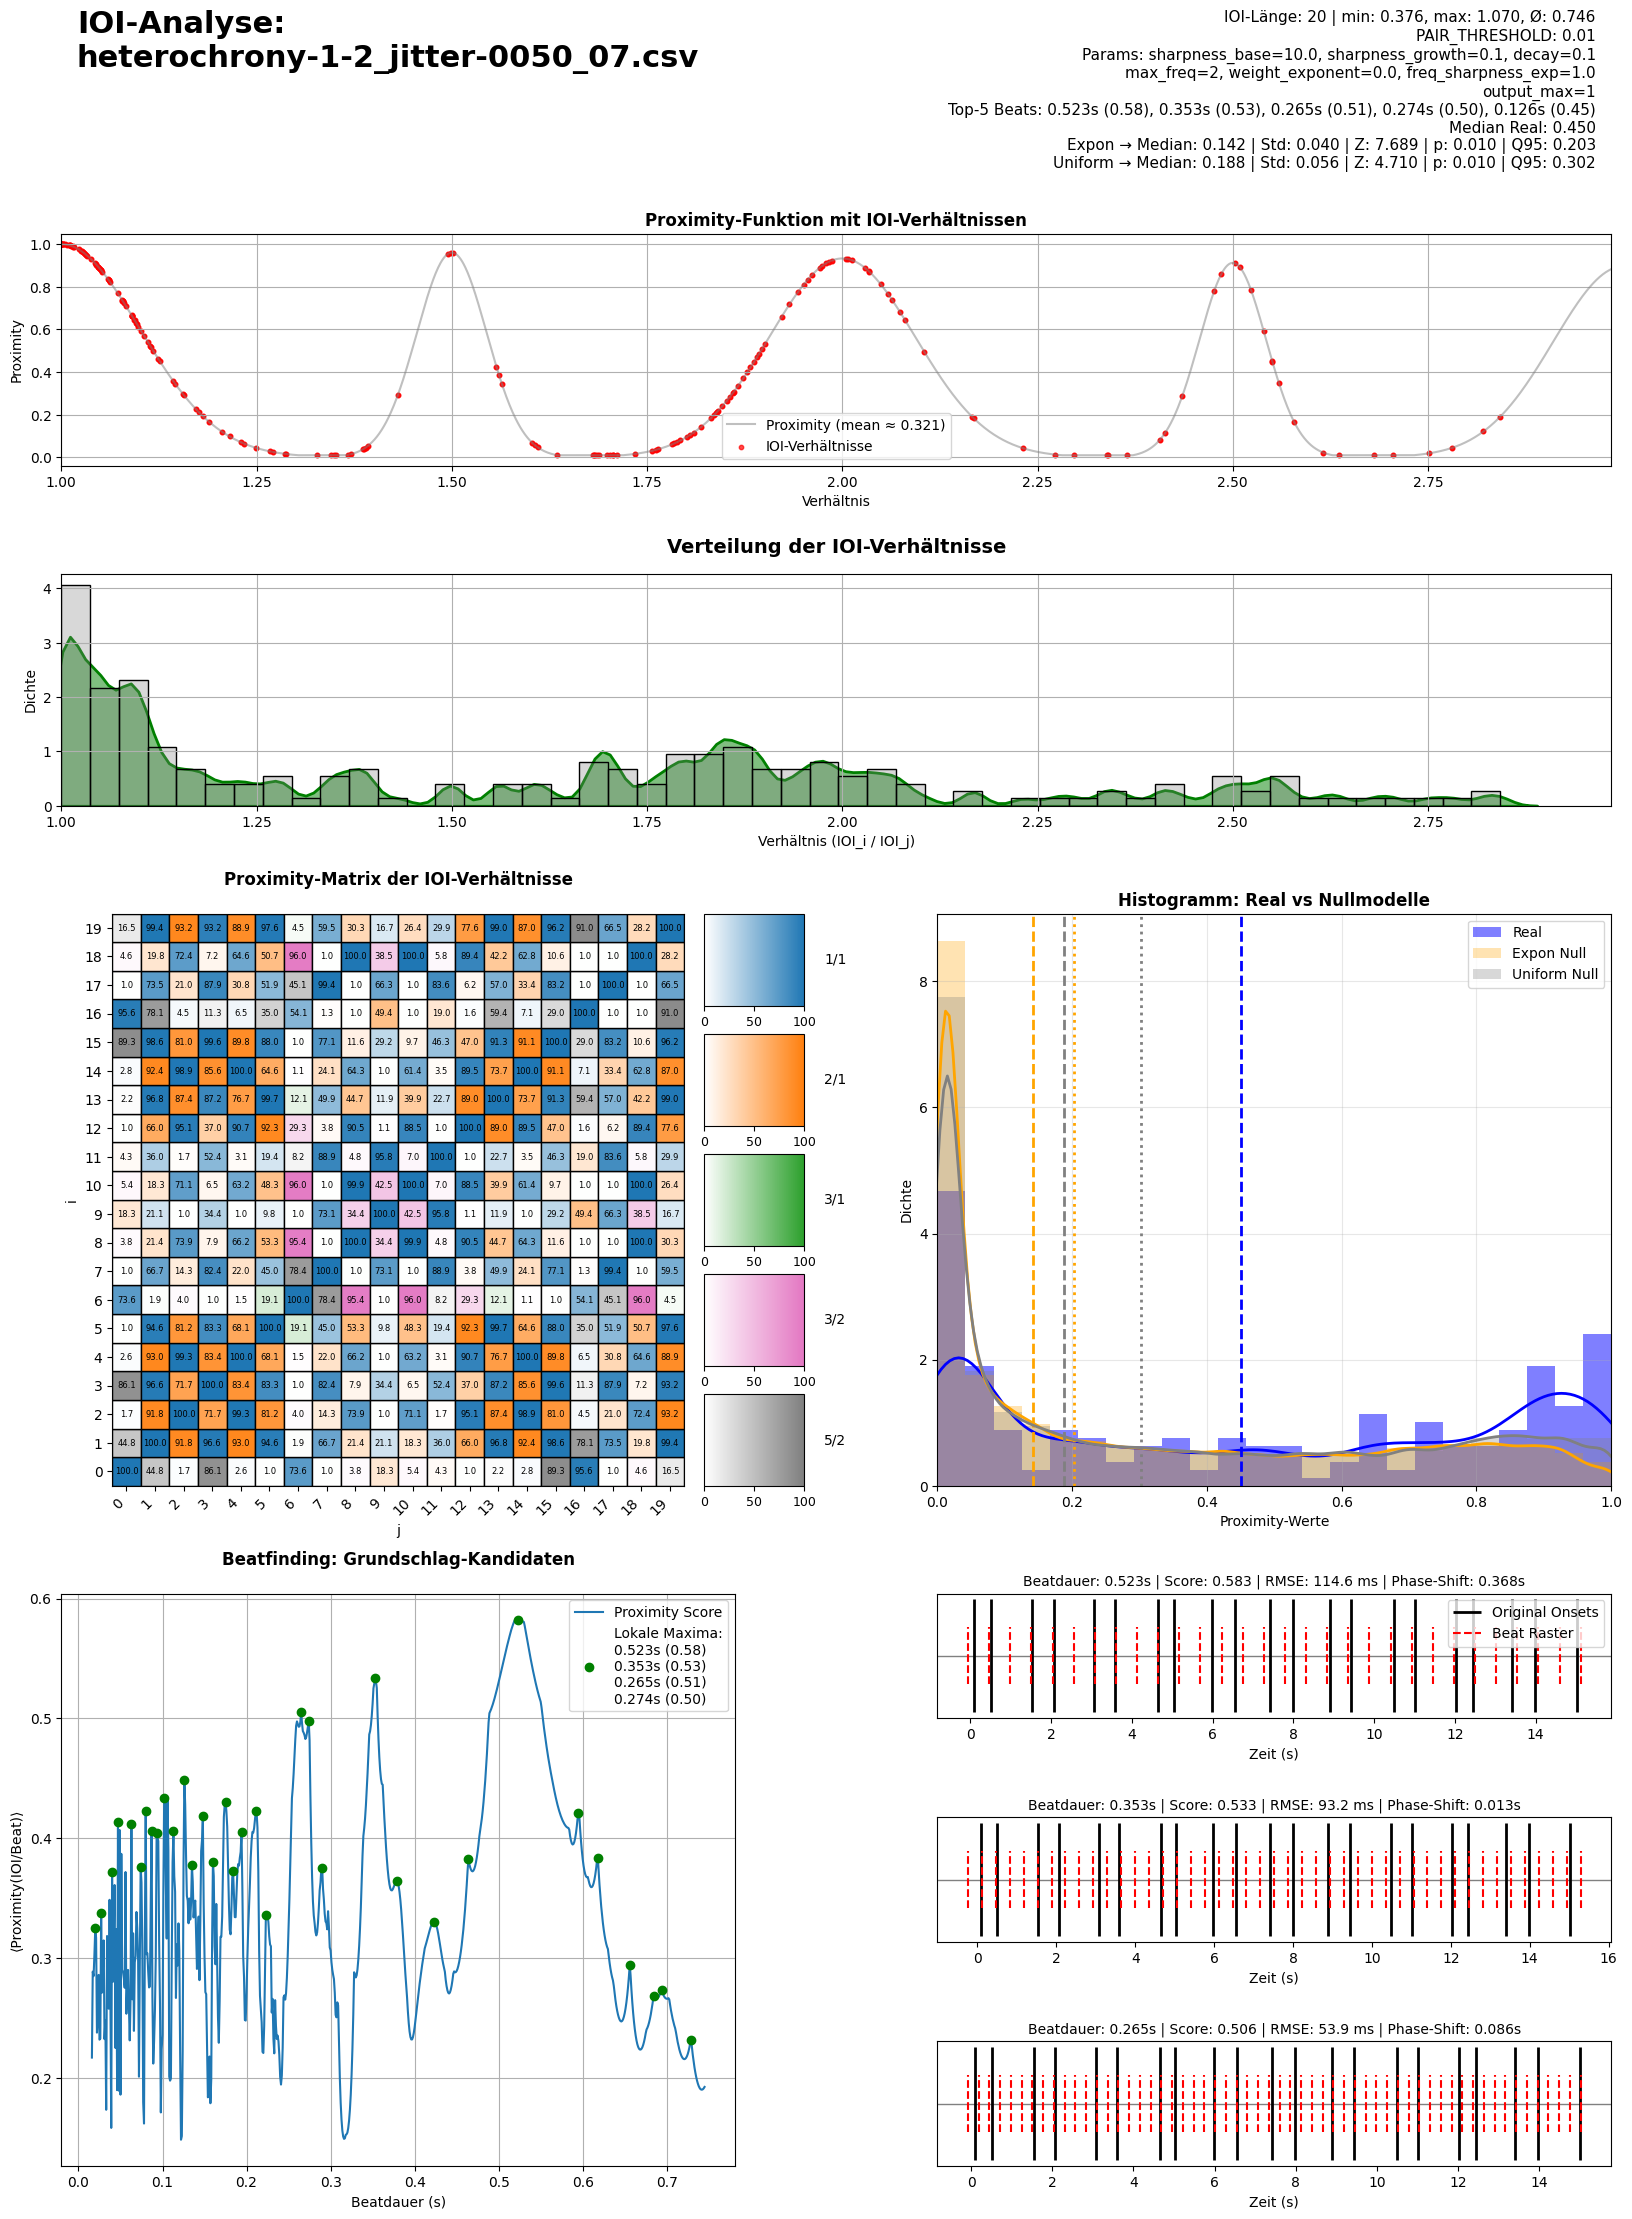

{'iois': array([0.40582074, 1.03515642, 0.52200729, 1.0086795 , 0.51574757,
        1.06970826, 0.37632648, 0.94965099, 0.56261156, 0.8800293 ,
        0.56512761, 0.9056884 , 0.53849793, 1.06157264, 0.5142956 ,
        1.01811567, 0.4180294 , 0.95983336, 0.56392738, 1.04648099]),
 'onsets': array([ 0.1       ,  0.50582074,  1.54097717,  2.06298445,  3.07166395,
         3.58741152,  4.65711978,  5.03344626,  5.98309726,  6.54570882,
         7.42573812,  7.99086572,  8.89655412,  9.43505206, 10.49662469,
        11.0109203 , 12.02903596, 12.44706536, 13.40689872, 13.9708261 ,
        15.01730709]),
 'results': {'proximity_real': array([0.44799307, 0.01659939, 0.86121633, 0.02551032, 0.01      ,
         0.73555847, 0.01      , 0.03845282, 0.18261853, 0.05410602,
         0.04268537, 0.01      , 0.02245647, 0.02808845, 0.89323132,
         0.95575668, 0.01      , 0.04608199, 0.16533295, 0.91772845,
         0.96613592, 0.93033626, 0.94581735, 0.01865951, 0.66674394,
         0.21411436

In [17]:
# übergeordneten Ordner hinzufügen
sys.path.append(str(Path("..").resolve()))

# Proximity-Library laden
from pathlib import Path
import proximitylib.proximity as prox
importlib.reload(prox)

# =============================
# 1) Parameter, Daten laden & Pairs bauen
# =============================
# =============================
# 0) Datei + Parameter Auswahl
# =============================

prox.plot_sequence_analysis(
    filename="heterochrony-1-2_jitter-0050_07.csv",
    base_dir="/Users/emilschmiedl/Desktop/Proximity-Funktion/data/theoretical_sequences/baseIOI-0.50/20beats/",
    param_choice=2,
    null_models=["expon", "uniform"],
    num_sequences=100
)
